In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv( 'cancer_classification.csv')

In [3]:
df.head(5)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,benign_0__mal_1
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [4]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


<AxesSubplot: xlabel='benign_0__mal_1', ylabel='count'>

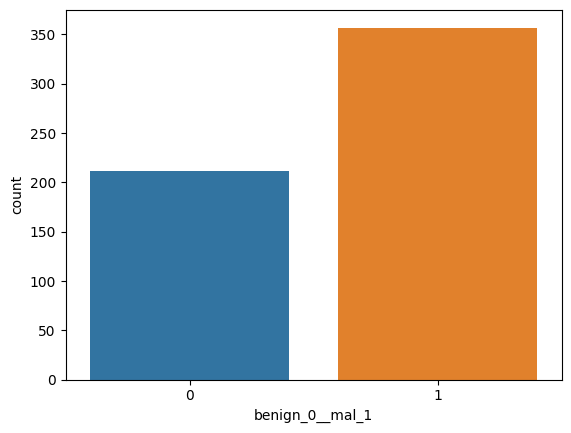

In [5]:
sns.countplot(x='benign_0__mal_1', data=df)

<AxesSubplot: >

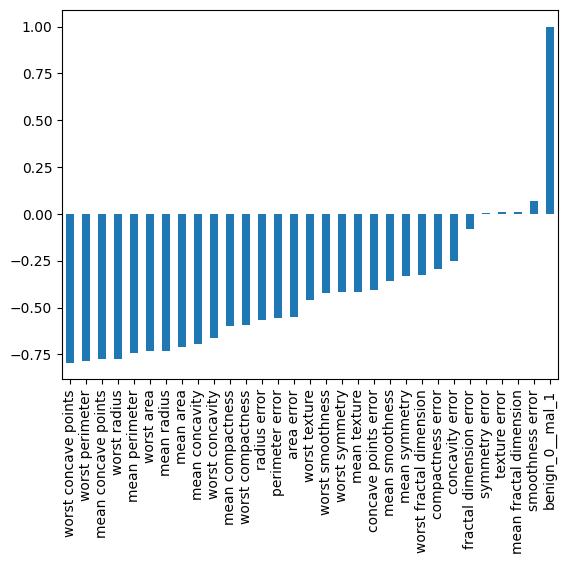

In [6]:
df.corr()['benign_0__mal_1'].sort_values().plot(kind='bar')

In [7]:
X= df.drop('benign_0__mal_1', axis=1).values
y= df['benign_0__mal_1'].values

In [8]:
X.shape

(569, 30)

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
y.shape

(569,)

In [11]:
X_train,X_test, y_train,y_test= train_test_split(X, y, test_size=0.25, random_state=101)

In [12]:
from sklearn.preprocessing import MinMaxScaler

In [13]:
scaler = MinMaxScaler()

In [14]:
X_train = scaler.fit_transform(X_train)

In [15]:
X_test = scaler.transform(X_test)

In [16]:
y_test.shape

(143,)

In [17]:
X_test.shape

(143, 30)

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

2023-04-13 17:10:46.700005: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-04-13 17:10:46.730212: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-04-13 17:10:46.881512: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-04-13 17:10:46.882405: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-04-13 17:10:47.911899: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Co

In [19]:
X_train.shape

(426, 30)

In [20]:
y_train.shape

(426,)

In [21]:
model = Sequential()

model.add(Dense(units=30,activation='relu'),)
model.add(Dense(units=15,activation='relu'),)

model.add(Dense(units=1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam')

In [22]:
model.fit(x=X_train,y=y_train,epochs=600,validation_data=(X_test,y_test))

Epoch 1/600
14/14 [==============================] - 1s 16ms/step - loss: 0.6952 - val_loss: 0.6687
Epoch 2/600
14/14 [==============================] - 0s 5ms/step - loss: 0.6541 - val_loss: 0.6330
Epoch 3/600
14/14 [==============================] - 0s 4ms/step - loss: 0.6171 - val_loss: 0.5947
Epoch 4/600
14/14 [==============================] - 0s 6ms/step - loss: 0.5767 - val_loss: 0.5503
Epoch 5/600
14/14 [==============================] - 0s 4ms/step - loss: 0.5317 - val_loss: 0.5022
Epoch 6/600
14/14 [==============================] - 0s 4ms/step - loss: 0.4881 - val_loss: 0.4591
Epoch 7/600
14/14 [==============================] - 0s 4ms/step - loss: 0.4459 - val_loss: 0.4184
Epoch 8/600
14/14 [==============================] - 0s 3ms/step - loss: 0.4063 - val_loss: 0.3772
Epoch 9/600
14/14 [==============================] - 0s 3ms/step - loss: 0.3686 - val_loss: 0.3430
Epoch 10/600
14/14 [==============================] - 0s 3ms/step - loss: 0.3357 - val_loss: 0.3095
Epoch 11